## Parte 3 — Relación matemática entre las bitácoras 1 y 2, y el modelo usado
**Andrés Zúñiga Mora C38733**  
**Luis Diego Elizondo Fennel**  
**Santiago Paniagua Chavarría C4I249**  
**Sebastián Calderón Segura C21517**

El modelo se usó en la parte 1 y 2 de este proyecto como una "caja negra", de manera que se usó sin comprender realmente los mecanismos que lo hacen funcionar, sin embargo, gran parte de estos son casi las mismas operaciones que ya se implementaron a mano en las bitácoras anteriores.

Un modelo como DistilBERT es como una combinación, bastante grande, de productos matriciales, funciones softmax, normalizaciones y capas lineales apiladas una encima de otra, entrenadas con descenso de gradiente. Eso se exploró en las bitácoras 1 y 2.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resultados reales obtenidos en la Parte 1 y 2 con distilbert-base-uncased-finetuned-sst-2-english
# sobre la muestra de 1000 reseñas del dataset IMDB (500 positivas, 500 negativas)

metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [0.900000, 0.921941, 0.874000, 0.897331]
})

matriz_confusion = np.array([[463, 37],
                              [63, 437]])

metricas

,Métrica,Valor
0,Accuracy,0.900000
1,Precision,0.921941
2,Recall,0.874000
3,F1-score,0.897331


## Recordatorio rápido de lo hecho en las Partes 1 y 2

Se usó el modelo `distilbert-base-uncased-finetuned-sst-2-english` a través de `pipeline("sentiment-analysis")` de Hugging Face, para clasificar reseñas de películas del dataset `stanfordnlp/imdb` en positivas o negativas. Con esa muestra de 1000 reseñas balanceadas se obtuvo un accuracy de 0.90, con 463 negativos y 437 positivos bien clasificados, y 100 errores en total (37 negativos etiquetados como positivos, 63 positivos etiquetados como negativos).

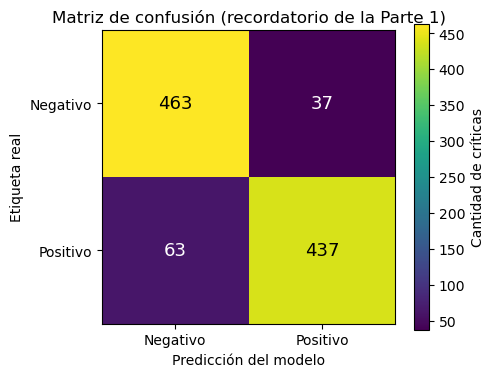

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matriz_confusion, cmap="viridis")

etiquetas = ["Negativo", "Positivo"]
ax.set_xticks([0, 1]); ax.set_xticklabels(etiquetas)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiquetas)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión (recordatorio de la Parte 1)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_confusion[i, j], ha="center", va="center",
                color="white" if matriz_confusion[i, j] < 300 else "black", fontsize=13)

plt.colorbar(im, ax=ax, label="Cantidad de críticas")
plt.tight_layout()
plt.show()

Con esto de fondo, empezamos a contestar la pregunta ¿qué hay matemáticamente dentro de ese `pipeline` que ya se haya trabajado en las anteriores bitácoras?

## 1. Los textos se convierten en tensores (Bitácora 1)

Antes de que DistilBERT pueda hacer cualquier cosa con una reseña de película, el texto tiene que dejar de ser texto. Cada *token* se convierte primero en un número mediante un vocabulario fijo, y luego ese número se convierte en un vector de varios cientos de valores reales, llamado *embedding*.

Entonces una reseña que originalmente era una cadena de texto termina representada como un tensor de forma `(batch, secuencia, dimensión)`: un lote de reseñas, cada una con cierta cantidad de tokens, y cada token representado por un vector. Esto es exactamente el tipo de objeto con el que se trabajó en la Bitácora 1 al hacer *reshaping*, *broadcasting* y operaciones por lotes con `einsum`. La diferencia es que ahí se trabajaba con tensores de ejemplo hechos a mano, y acá el tensor contiene información semántica del lenguaje, pero la estructura matemática (arreglos multidimensionales que se combinan con productos matriciales) es la misma.

De hecho, en la Bitácora 1 ya se había armado la función `batch_matmul`, pensada justo para lotes de secuencias con múltiples cabezas de atención, con la notación `"bhid,bhjd->bhij"`. Eso no era un ejercicio suelto: es prácticamente la operación central que usa cualquier Transformer, incluido DistilBERT.

## 2. La atención es producto punto más softmax

DistilBERT se basa en el mecanismo de **auto-atención** (self-attention). Para cada palabra, el modelo calcula qué tan "relacionada" está con cada una de las otras palabras de la oración, y usa esas relaciones para decidir qué información combinar.

Esa relación se calcula con un producto punto entre vectores (los llamados *query* y *key*), y el producto punto es justamente la operación que se trabajó en la Bitácora 1 en la sección de productos vectoriales, donde ya se había anotado que el producto punto funciona como una medida de similitud y que por eso es la base de la atención en los Transformers. Cuanto más alineados estén dos vectores, mayor el producto punto, y mayor el peso que una palabra le da a la otra.

Una vez que se tienen esos productos punto, hay que convertirlos en algo que se pueda interpretar como una distribución de pesos que sume 1. Ahí entra el **softmax**, la misma función implementada en la Bitácora 1, con el mismo truco de estabilidad numérica (restar el máximo antes de exponenciar).

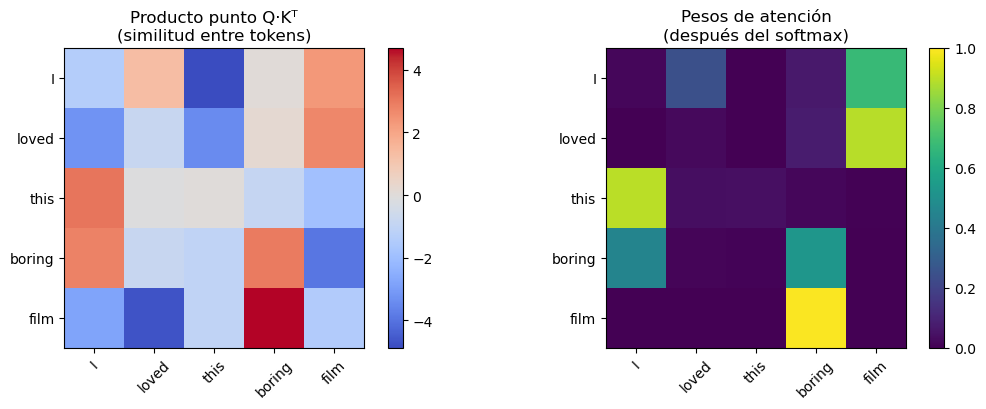

Suma de cada fila de pesos de atención (debe dar 1): [1. 1. 1. 1. 1.]


In [5]:
def softmax_estable(x):
    """Misma función softmax de la Bitácora 1, aplicada por fila."""
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Simulamos 5 tokens con vectores query/key de dimensión 8 (representativo, no son los reales del modelo, solo sirven para ilustrar la mecánica matemática)
np.random.seed(7)
tokens = ["I", "loved", "this", "boring", "film"]
Q = np.random.randn(5, 8)
K = np.random.randn(5, 8)

scores = Q @ K.T                      # lo mismo que batch_matmul de la Bitácora 1, para una sola cabeza
pesos_atencion = softmax_estable(scores)   # cada fila suma 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

im0 = axes[0].imshow(scores, cmap="coolwarm")
axes[0].set_title("Producto punto Q·Kᵀ\n(similitud entre tokens)")
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(tokens, rotation=45)
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(tokens)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(pesos_atencion, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Pesos de atención\n(después del softmax)")
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(tokens, rotation=45)
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(tokens)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

print("Suma de cada fila de pesos de atención (debe dar 1):", np.round(pesos_atencion.sum(axis=1), 4))

El panel izquierdo son los productos punto crudos: entre más parecidos (o más alineados) sean dos vectores de tokens, más alto (más rojo) el valor. El panel derecho es lo mismo, pero después de pasar por softmax: ya son pesos entre 0 y 1 que suman 1 por fila, listos para usarse como un promedio ponderado de los demás tokens. Esto es una versión reducida y simbólica (5 tokens, 8 dimensiones) de lo que hace cada cabeza de atención dentro de DistilBERT, solo que ahí son 12 cabezas por capa, 6 capas, y vectores de 768 dimensiones. La mecánica de fondo, sin embargo, es idéntica.

## 3. Las capas del Transformer son las piezas de la Bitácora 2

Después de calcular la atención, cada capa del Transformer sigue combinando esos vectores con operaciones que ya se implementaron a mano en la Bitácora 2:

- **Capas lineales.** Los vectores *query*, *key* y *value* se obtienen aplicando una transformación lineal $y = xW + b$ sobre el embedding de cada token, eso es exactamente la función `linear_forward` programada en la Bitácora 2. Lo mismo pasa con la capa de salida de cada bloque de atención y con el bloque feed-forward que viene después. Un Transformer es como una torre de capas lineales intercaladas con no linealidades y normalizaciones.

- **Activaciones no lineales.** En la Bitácora 2 se trabajó con ReLU, sigmoid y tanh. DistilBERT usa una variante llamada GELU en sus bloques feed-forward, con forma distinta pero el mismo propósito que ReLU: romper la linealidad para que apilar capas realmente sirva de algo. Sin una función de activación no lineal, varias capas lineales consecutivas serían equivalentes a una sola transformación lineal.

- **Layer Normalization.** En la Bitácora 2, en la explicación de LayerNorm ya se había anotado que esta técnica "no depende del tamaño del batch, lo que lo hace ideal para modelos de lenguaje y transformers". Eso es lo que usa DistilBERT después de cada bloque de atención y de cada bloque feed-forward, en vez de Batch Normalization. La fórmula es la misma: normalizar cada token con su propia media y varianza a lo largo de sus features, y reescalar con $\gamma$ y $\beta$ aprendibles.

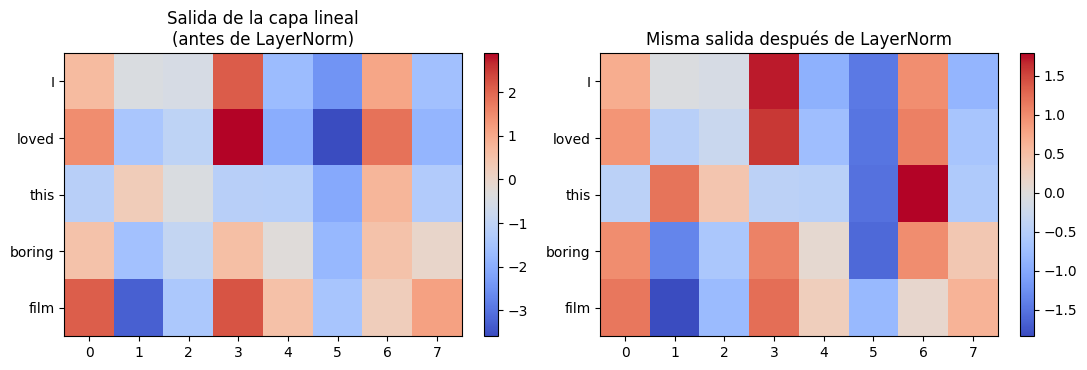

Media por fila antes de normalizar:      [-0.358 -0.462 -0.787 -0.376  0.007]
Media por fila después de LayerNorm:     [ 0.  0. -0.  0.  0.]
Varianza por fila después de LayerNorm:  [1. 1. 1. 1. 1.]


In [4]:
def linear_forward(x, w, b):
    """Misma función de la Bitácora 2: y = xW + b"""
    return x @ w + b

def layernorm(x, gamma, beta, eps=1e-5):
    """Misma función de la Bitácora 2, normalizando por fila (por token)"""
    mean = x.mean(axis=1, keepdims=True)
    var = x.var(axis=1, keepdims=True)
    x_norm = (x - mean) / np.sqrt(var + eps)
    return gamma * x_norm + beta

np.random.seed(3)
salida_atencion = pesos_atencion @ np.random.randn(5, 8)   # combinamos valores usando los pesos de atención

W = np.random.randn(8, 8) * 0.6
b = np.zeros(8)
z = linear_forward(salida_atencion, W, b)                 # capa lineal tipo feed-forward

gamma = np.ones(8)
beta = np.zeros(8)
z_normalizado = layernorm(z, gamma, beta)                  # LayerNorm, igual que en la Bitácora 2

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
im0 = axes[0].imshow(z, cmap="coolwarm", aspect="auto")
axes[0].set_title("Salida de la capa lineal\n(antes de LayerNorm)")
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(tokens)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(z_normalizado, cmap="coolwarm", aspect="auto")
axes[1].set_title("Misma salida después de LayerNorm")
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(tokens)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

print("Media por fila antes de normalizar:     ", np.round(z.mean(axis=1), 3))
print("Media por fila después de LayerNorm:    ", np.round(z_normalizado.mean(axis=1), 3))
print("Varianza por fila después de LayerNorm: ", np.round(z_normalizado.var(axis=1), 3))

El primer gráfico muestra los valores de los embeddings de cada token después de la transformación lineal.  
El segundo muestra los mismos embeddings después de aplicar LayerNorm.  
Se nota en los números: antes de normalizar, cada token tiene su propia media (a veces alejada de cero); después de aplicar LayerNorm, todas las filas quedan con media cerca de 0 y varianza cerca de 1, sin importar cómo venía cada token. Esto evita que la escala de los valores se dispare o se apague al pasar por las 6 capas de DistilBERT, que es justo el problema que la Bitácora 2 explicaba que resuelve esta técnica.

## 4. Cómo se entrenó el modelo: pérdida, gradientes y optimizador

El modelo que se usó ya viene entrenado (fine-tuneado sobre SST-2), así que en las Partes 1 y 2 no se entrenó nada, solo se hizo inferencia. Pero vale la pena conectar cómo se llegó a esos pesos, porque ahí también aparecen conceptos directos de las bitácoras.

**La capa final y el softmax.** La última capa de DistilBERT para esta tarea produce dos logits (uno por clase). El `pipeline` convierte esos logits en probabilidades con un softmax, y el valor reportado como `confianza_modelo` en la Parte 1 es esa probabilidad.

**La función de pérdida.** Para ajustar los pesos durante el fine-tuning, se compara esa probabilidad contra la etiqueta real usando cross-entropy, la misma función `cross_entropy_loss` implementada en la Bitácora 1. Esto indica que cuanto más lejos esté la probabilidad predicha de la clase correcta, mayor la pérdida. Puede interpretarse como una "penalización" por cada predicción. Cuanto más lejos esté la predicción de la respuesta correcta, mayor será el ajuste de sus parámetros durante el entrenamiento.

**Los gradientes y el optimizador.** Esa pérdida se propaga hacia atrás con la regla de la cadena, el mismo principio aplicado a mano en `linear_backward` y en `categorical_ce_backward` en la Bitácora 2. Los pesos se ajustan con **AdamW**, una variante de **Adam**, el optimizador implementado en la Bitácora 2 con sus dos acumuladores de momento y su corrección de sesgo.

**Inicialización y Dropout.** Antes de empezar cualquier entrenamiento, los pesos de una red como esta se inicializan con esquemas parecidos a Xavier o Kaiming  y durante el entrenamiento se usa dropout para evitar que el modelo memorice el dataset de entrenamiento en vez de aprender un patrón generalizable. Ambas cosas, se exploraron en la Bitácora 2.

A continuación se usan los 10 errores reales reportados en la Parte 1 para ver esto con números concretos: qué tan "cara" le sale al modelo cada equivocación según la fórmula de cross-entropy.

In [6]:
# Los 10 errores reales reportados en la Parte 1, con el texto (resumido), la etiqueta real,
# lo que predijo el modelo y la confianza que le puso a esa predicción incorrecta.
errores_reales = pd.DataFrame({
    "texto": [
        "I agree that this movie is about sex without...",
        "Let's not beat about the bush here, Taylor Hac...",
        "Dude, I thought this movie rocked. Perfect for...",
        "I caught this film -- under the title of What...",
        "Graphics is far from the best part of the game...",
        "This movie was very good, not great but very g...",
        "The filmmakers apparently had enough money to...",
        "One of the classic low budget 70's movies, thi...",
        "Poor Bela Lugosi. Just another day at work. A...",
        "Someone told me that Pink Flamingos was, in a...",
    ],
    "real": ["Negativo", "Positivo", "Positivo", "Negativo", "Positivo",
             "Positivo", "Negativo", "Positivo", "Negativo", "Negativo"],
    "predicho": ["Positivo", "Negativo", "Negativo", "Positivo", "Negativo",
                 "Negativo", "Positivo", "Negativo", "Positivo", "Positivo"],
    "confianza_en_error": [0.965816, 0.970311, 0.952877, 0.996707, 0.974262,
                            0.797934, 0.942509, 0.999080, 0.990237, 0.627598],
})

def cross_entropy_binaria(prob_predicha, acierto, eps=1e-9):
    """Misma lógica de cross_entropy_loss de la Bitácora 1, para un solo ejemplo binario."""
    return -np.log(prob_predicha + eps) if acierto else -np.log(1 - prob_predicha + eps)

# Como el modelo se equivocó en los 10 casos, la probabilidad que le dio a la clase CORRECTA es 1 - confianza_en_error. 
errores_reales["prob_clase_correcta"] = 1 - errores_reales["confianza_en_error"]
errores_reales["perdida_cross_entropy"] = errores_reales["confianza_en_error"].apply(
    lambda c: cross_entropy_binaria(1 - c, acierto=True)
)

errores_reales[["texto", "real", "predicho", "confianza_en_error",
                "prob_clase_correcta", "perdida_cross_entropy"]].round(4)

,texto,real,predicho,confianza_en_error,prob_clase_correcta,perdida_cross_entropy
0,I agree that this movie is about sex without...,Negativo,Positivo,0.9658,0.0342,3.3760
1,"Let's not beat about the bush here, Taylor Hac...",Positivo,Negativo,0.9703,0.0297,3.5170
2,"Dude, I thought this movie rocked. Perfect for...",Positivo,Negativo,0.9529,0.0471,3.0550
3,I caught this film -- under the title of What...,Negativo,Positivo,0.9967,0.0033,5.7160
4,Graphics is far from the best part of the game...,Positivo,Negativo,0.9743,0.0257,3.6598
5,"This movie was very good, not great but very g...",Positivo,Negativo,0.7979,0.2021,1.5992
6,The filmmakers apparently had enough money to...,Negativo,Positivo,0.9425,0.0575,2.8561
7,"One of the classic low budget 70's movies, thi...",Positivo,Negativo,0.9991,0.0009,6.9911
8,Poor Bela Lugosi. Just another day at work. A...,Negativo,Positivo,0.9902,0.0098,4.6292
9,"Someone told me that Pink Flamingos was, in a...",Negativo,Positivo,0.6276,0.3724,0.9878


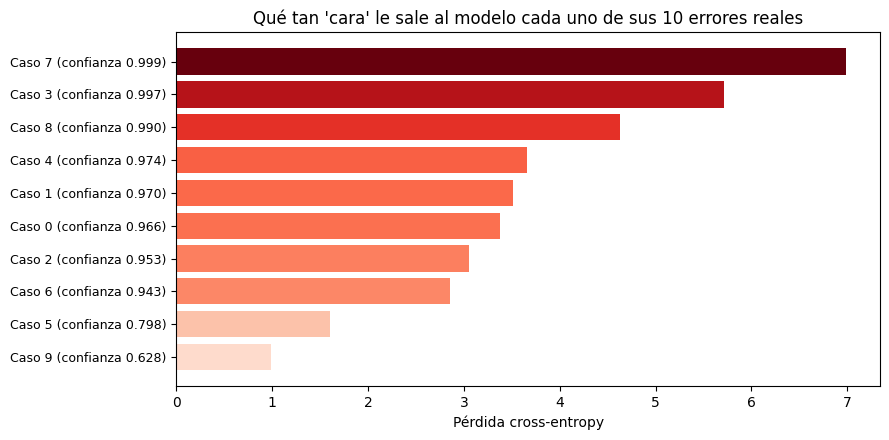

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
orden = errores_reales.sort_values("perdida_cross_entropy")
colores = plt.cm.Reds(orden["perdida_cross_entropy"] / orden["perdida_cross_entropy"].max())

ax.barh(range(10), orden["perdida_cross_entropy"], color=colores)
ax.set_yticks(range(10))
ax.set_yticklabels([f"Caso {i} (confianza {c:.3f})" for i, c in
                     zip(orden.index, orden["confianza_en_error"])], fontsize=9)
ax.set_xlabel("Pérdida cross-entropy")
ax.set_title("Qué tan 'cara' le sale al modelo cada uno de sus 10 errores reales")
plt.tight_layout()
plt.show()

El caso con confianza de 0.999080 (el modelo estaba casi seguro de que su respuesta incorrecta era correcta) genera una pérdida cross-entropy mucho más alta que el caso con confianza 0.627598. Cross-entropy loss se usa en el entrenamiento para el entrenamiento porque además de penalizar los fallos, penaliza mucho más fuerte equivocarse estando muy seguro. 

## 5. Tabla resumen: de las bitácoras al modelo

| Concepto explorado en las bitácoras | Dónde aparece dentro de DistilBERT |
|---|---|
| Tensores, reshape, broadcasting, `einsum` (Bitácora 1) | Los embeddings de tokens y sus operaciones por lote |
| Producto punto y `batch_matmul` (Bitácora 1) | El cálculo de similitud Q·Kᵀ en cada cabeza de atención |
| Softmax estable (Bitácora 1) | Normalización de los pesos de atención y de los logits finales |
| Cross-entropy loss (Bitácora 1) | Función de pérdida usada para el fine-tuning en SST-2 |
| Capa lineal `linear_forward` / `linear_backward` (Bitácora 2) | Proyecciones Q, K, V y las capas feed-forward |
| ReLU / sigmoid / tanh (Bitácora 2) | GELU, la no linealidad de los bloques feed-forward |
| Layer Normalization (Bitácora 2) | Normalización después de cada bloque de atención y feed-forward |
| Dropout (Bitácora 2) | Regularización durante el entrenamiento del modelo |
| Xavier / Kaiming init (Bitácora 2) | Inicialización de los pesos antes de entrenar |
| SGD, Momentum, Adam (Bitácora 2) | AdamW, el optimizador usado para ajustar los pesos |

## 6. Conclusión

Si se observa el modelo por partes deja de ser esa "caja negra", vemos que este usa piezas que ya exploramos en las bitácoras 1 y 2, lo que cambia es la escala: tokens convertidos en tensores, productos punto y softmax para calcular atención, capas lineales y LayerNorm para transformar esa información capa tras capa, y al final una pérdida tipo cross-entropy que, junto con Adam y backpropagation, fue la que ajustó los pesos del modelo durante su entrenamiento.

## 7. Referencias
Alammar, J. (2019). A Visual Guide to Using BERT for the First Time. https://jalammar.github.io/illustrated-bert/  
Alammar, J. (2018). The Illustrated Transformer. https://jalammar.github.io/illustrated-transformer/  
Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. Proceedings of NAACL-HLT 2019, 4171–4186. https://arxiv.org/abs/1810.04805  
Hugging Face. (s. f.). DistilBERT. https://huggingface.co/docs/transformers/model_doc/distilbert  
Rush, A. M. (2018). The Annotated Transformer. Harvard NLP. https://nlp.seas.harvard.edu/annotated-transformer/  
Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter. https://arxiv.org/abs/1910.01108  
Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). Attention Is All You Need. Advances in Neural Information Processing Systems, 30. https://arxiv.org/abs/1706.03762   
Attention Is All You Need. Advances in Neural Information Processing Systems, 30. https://arxiv.org/abs/1706.03762

